<a href="https://colab.research.google.com/github/gaurangistp-glitch/DATA-SCIENCE-AND-AI/blob/main/DATA_ANALYSIS_AND_VISUALISATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***OBJECTIVES***

Understand the structure of data.

Find missing values.

Detect outliers.

Analyze distribution.

Find relationships vbetween variables.

Generate buisness insights.

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB
None
Shape: (418, 2)
Columns: Index(['PassengerId', 'Survived'], dtype='object')
       PassengerId    Survived
count   418.000000  418.000000
mean   1100.500000    0.366029
std     120.810458    0.482295
min     892.000000    0.000000
25%     996.250000    0.000000
50%    1100.500000    0.000000
75%    1204.750000    1.000000
max    1309.000000    1.000000
PassengerId    0
Survived       0
dtype: int64
Duplicates: 0
             PassengerId  Survived
PassengerId      1.00000  -0.05015
Survived        -0.05015   1.00000
Survived
0    265
1   

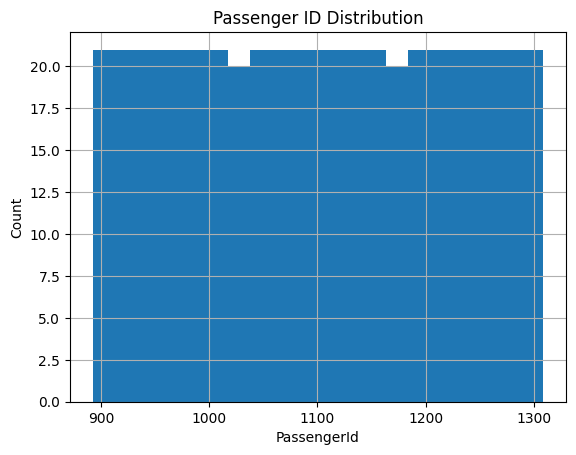

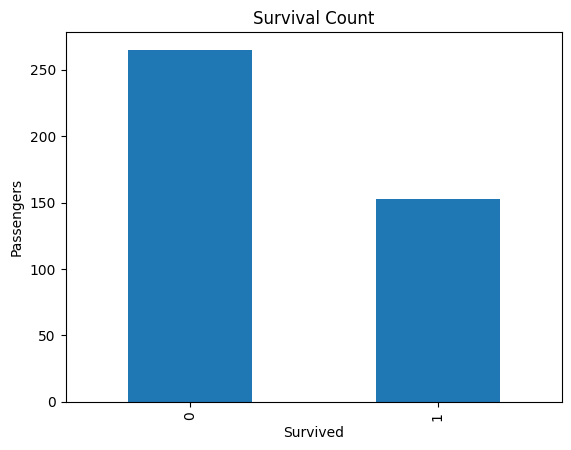

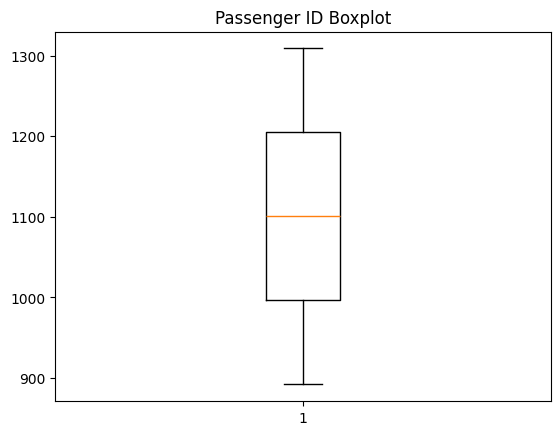

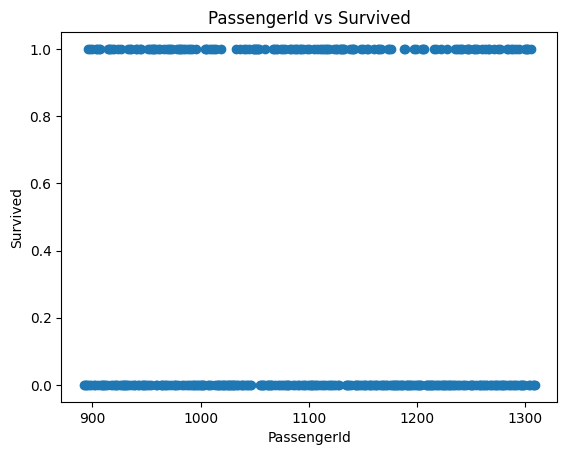

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("titanic.csv")

# First 5 rows
print(df.head())

# Dataset Information
print(df.info())

# Shape
print("Shape:", df.shape)

# Columns
print("Columns:", df.columns)

# Statistical Summary
print(df.describe())

# Missing Values
print(df.isnull().sum())

# Duplicate Rows
print("Duplicates:", df.duplicated().sum())

# Correlation
print(df.corr())

# Value Counts
print(df["Survived"].value_counts())

# Histogram
df["PassengerId"].hist(bins=20)
plt.title("Passenger ID Distribution")
plt.xlabel("PassengerId")
plt.ylabel("Count")
plt.show()

# Bar Chart
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Passengers")
plt.show()

# Box Plot
plt.boxplot(df["PassengerId"])
plt.title("Passenger ID Boxplot")
plt.show()

# Scatter Plot
plt.scatter(df["PassengerId"], df["Survived"])
plt.xlabel("PassengerId")
plt.ylabel("Survived")
plt.title("PassengerId vs Survived")
plt.show()

# ***DATA TRANSFORMATION***

Data Transformation is the process of converting raw data into a cleaner and more suitable format for analysis or machine learning.

**Common** **Transformation**

Missing values Treatment

Encoding

Scaling

Normalisation

Standardization

Log Transformation

Binning

Data Type Conversion



In [ ]:
import pandas as pd
import numpy as np

# Import required libraries
# Pandas -> Data Manipulation
# NumPy -> Mathematical Operations

# ============================================
# Load Dataset
# ============================================

# Read CSV file into a DataFrame
df = pd.read_csv("/content/titanic.csv")

print("Original Dataset")
print(df.head())

# ============================================
# 1. Check Missing Values
# Concept: Identify null (missing) values in each column.
# ============================================

print("\nMissing Values")
print(df.isnull().sum())

# ============================================
# 2. Fill Missing Values
# Concept: Replace missing values with suitable values.
# ============================================

# Fill missing PassengerId with Mean
df["PassengerId"] = df["PassengerId"].fillna(df["PassengerId"].mean())

# Fill missing Survived values with Mode
df["Survived"] = df["Survived"].fillna(df["Survived"].mode()[0])

print("\nAfter Filling Missing Values")
print(df.isnull().sum())

# ============================================
# 3. Remove Duplicate Rows
# Concept: Remove repeated records from the dataset.
# ============================================

print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

# ============================================
# 4. Data Type Conversion
# Concept: Convert data into the required data type.
# ============================================

df["PassengerId"] = df["PassengerId"].astype(int)
df["Survived"] = df["Survived"].astype(int)

print("\nData Types")
print(df.dtypes)

# ============================================
# 5. Create Categorical Column
# Concept: Convert numeric values into meaningful categories.
# ============================================

df["Status"] = df["Survived"].map({
    0: "Not Survived",
    1: "Survived"
})

print("\nStatus Column")
print(df.head())

# ============================================
# 6. Binning
# Concept: Divide continuous values into different groups.
# ============================================

df["PassengerGroup"] = pd.cut(
    df["PassengerId"],
    bins=4,
    labels=["Group A", "Group B", "Group C", "Group D"]
)

print("\nPassenger Groups")
print(df.head())

# ============================================
# 7. Standardization (Z-Score)
# Concept: Scale data with Mean = 0 and Standard Deviation = 1.
# ============================================

df["PassengerId_Standard"] = (
    df["PassengerId"] - df["PassengerId"].mean()
) / df["PassengerId"].std()

# ============================================
# 8. Min-Max Normalization
# Concept: Scale values between 0 and 1.
# ============================================

df["PassengerId_Normalized"] = (
    df["PassengerId"] - df["PassengerId"].min()
) / (
    df["PassengerId"].max() - df["PassengerId"].min()
)

# ============================================
# 9. Log Transformation
# Concept: Reduce skewness by compressing large values.
# ============================================

df["PassengerId_Log"] = np.log1p(df["PassengerId"])

# ============================================
# 10. Square Root Transformation
# Concept: Reduce the impact of large values.
# ============================================

df["PassengerId_Sqrt"] = np.sqrt(df["PassengerId"])

# ============================================
# 11. Square Transformation
# Concept: Increase the effect of larger values.
# ============================================

df["PassengerId_Square"] = df["PassengerId"] ** 2

# ============================================
# 12. Rank Transformation
# Concept: Assign ranking based on the values.
# ============================================

df["PassengerId_Rank"] = df["PassengerId"].rank()

# ============================================
# Final Dataset
# ============================================

# Display transformed dataset
print("\nTransformed Dataset")
print(df.head())

# Display dataset information
print("\nDataset Information")
print(df.info())

# ============================================
# Save Dataset
# Concept: Export transformed dataset to a CSV file.
# ============================================

df.to_csv("transformed_titanic.csv", index=False)

print("\nTransformed dataset saved successfully.")

Original Dataset
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1

Missing Values
PassengerId    0
Survived       0
dtype: int64

After Filling Missing Values
PassengerId    0
Survived       0
dtype: int64

Duplicate Rows: 0
Shape After Removing Duplicates: (418, 2)

Data Types
PassengerId    int64
Survived       int64
dtype: object

Status Column
   PassengerId  Survived        Status
0          892         0  Not Survived
1          893         0  Not Survived
2          894         0  Not Survived
3          895         0  Not Survived
4          896         1      Survived

Passenger Groups
   PassengerId  Survived        Status PassengerGroup
0          892         0  Not Survived        Group A
1          893         0  Not Survived        Group A
2          894         0  Not Survived        Group A
3          895         0  Not Survived        Group A
4          896         1   

# ***FEATURE ENGINEERING BASIC***

Feature engineering is gthe process of creating new useful features from existing data to improve the performance of learning models.

# ***MATPLOTOLIB***

Matplotlib is the most poplular python library used for creating data visualisation . It converts numerical data into meaningful charts and graphs that helps users analyse trends, patterns and comparisions.

# ***FEATURES OF MATPLOTLIB***

Open Source

Highly Customizable

Supports 20+ Chart type

Publication Quality Charts

Works perfectly with NumPy and Pandas

Can save images in PNG, JPG, PDF, SVG

In [1]:
pip install matplotlib

In [2]:
import matplotlib as plt

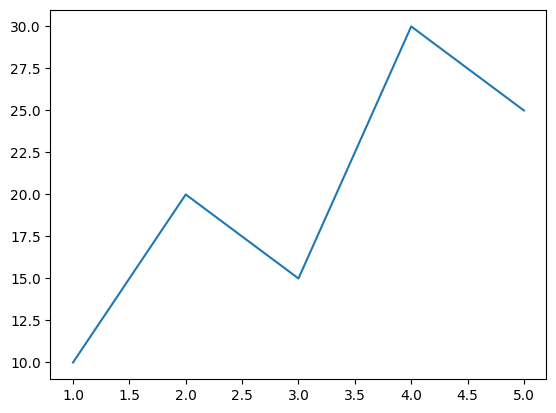

In [3]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4 ,5]
y = [10, 20, 15, 30, 25]

plt.plot(x, y)
plt.show()